In [ ]:
# Data Preprocessing
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences #Import pad_sequences from the correct module in TensorFlow/Keras.
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split

# Load data
data = pd.read_excel("/content/drive/MyDrive/cleaned_Twitter_Full1.xlsx")

def clean_text(text):
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove non-alphabetic characters (punctuation, numbers, etc.)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert text to lowercase
    text = text.lower()
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply text cleaning
data['cleaned_text'] = data['text'].apply(clean_text)

# Split data into training and validation sets
train_texts, val_texts, train_labels, val_labels = train_test_split(
    data['cleaned_text'].tolist(), data['labels'].tolist(), test_size=0.2, random_state=42
)

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(train_texts)

X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_test_seq = tokenizer.texts_to_sequences(val_texts)

X_train_pad = pad_sequences(X_train_seq, maxlen=150)  # Increased sequence length
X_test_pad = pad_sequences(X_test_seq, maxlen=150)

y_train = np.array(train_labels, dtype=np.float32)
y_test = np.array(val_labels, dtype=np.float32)

X_train_pad = np.array(X_train_pad, dtype=np.float32)
X_test_pad = np.array(X_test_pad, dtype=np.float32)

print(f"Shape of X_train_pad: {X_train_pad.shape}")
print(f"Shape of X_test_pad: {X_test_pad.shape}")

# Class weights
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: weight for i, weight in enumerate(class_weights)}


Shape of X_train_pad: (9008, 150)
Shape of X_test_pad: (2252, 150)


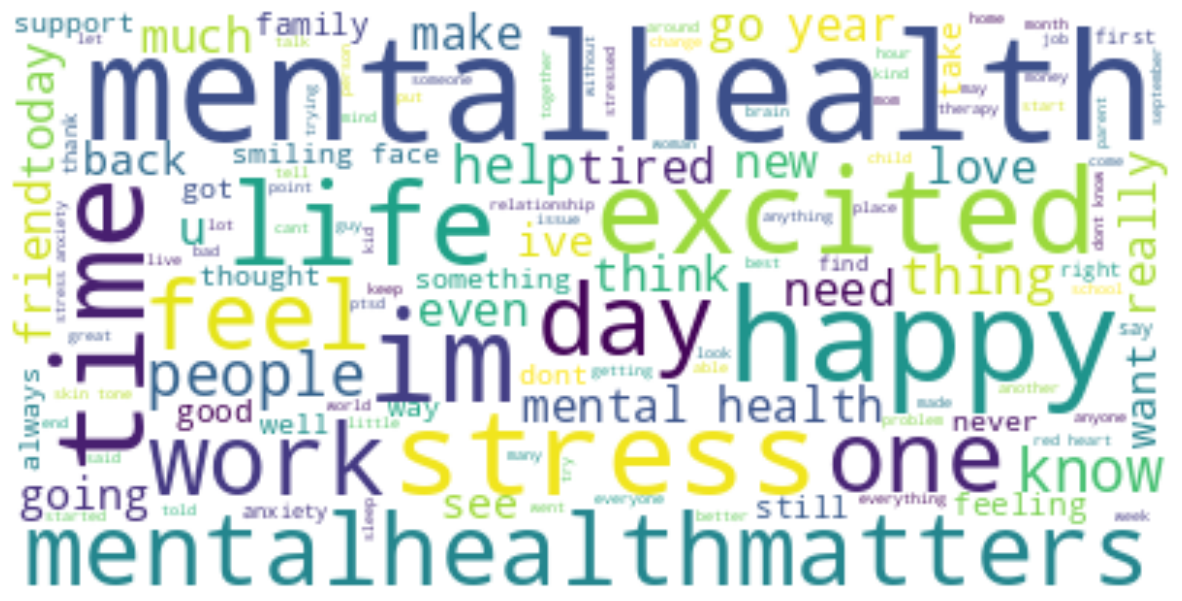

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
text = " ".join(i for i in data.text)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords,
                      background_color="white").generate(text)
plt.figure( figsize=(15,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
# Load GloVe Embeddings
def load_glove_embeddings(embedding_dim, vocab_size, word_index):
    embeddings_index = {}
    with open(f'/content/drive/MyDrive/Colab Notebooks/glove.6B.100d.txt', 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs

    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    for word, i in word_index.items():
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

    return embedding_matrix

# Create the embedding matrix
embedding_dim = 100
embedding_matrix = load_glove_embeddings(embedding_dim, len(tokenizer.word_index) + 1, tokenizer.word_index)
vocab_size = min(len(tokenizer.word_index) + 1, embedding_matrix.shape[0])


In [ ]:
from keras.models import Model
from keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, Input, Attention, GlobalAveragePooling1D, BatchNormalization
from keras.optimizers import Adam
from keras.regularizers import l2
import tensorflow as tf

def create_lstm_model_with_attention(vocab_size, embedding_dim, input_length, embedding_matrix):
    # Input layer
    inputs = Input(shape=(input_length,))

    # Pre-trained GloVe embedding layer
    x = Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length,
                  weights=[embedding_matrix], trainable=True)(inputs)  # Embedding is trainable

    # Stacked Bidirectional LSTM layers with regularization
    x = Bidirectional(LSTM(512, return_sequences=True, kernel_regularizer=l2(1e-4)))(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting
    x = Bidirectional(LSTM(256, return_sequences=True, kernel_regularizer=l2(1e-4)))(x)
    x = BatchNormalization()(x)  # Batch normalization to stabilize training

    # Attention layer - Pass the same output as both query and value
    attention_output = Attention()([x, x])

    # Take the mean of the attention output to get a single vector
    x = GlobalAveragePooling1D()(attention_output)

    # Fully connected layers with L2 regularization and Batch Normalization
    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)  # Dropout to further regularize

    x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)  # Dropout to further regularize

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)

    # Create the model
    model = Model(inputs, outputs)

    # Compile the model
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1e-4), metrics=['accuracy'])

    return model

# Create the model with attention
with strategy.scope():
    lstm_model_attention = create_lstm_model_with_attention(vocab_size, embedding_dim, 150, embedding_matrix)



In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)  # Adjust the learning rate when performance plateaus

# Train the model
history = lstm_model_attention.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=20,  # Increased epochs to 250 for more training cycles
    batch_size=128,  # You can tune this between 32, 64, or 128 for best results
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]  # Added learning rate reduction
)
train_accuracy = history.history['accuracy'][-1]  # Last epoch training accuracy
val_accuracy = history.history['val_accuracy'][-1]  # Last epoch validation accuracy

# Print out the accuracies
print(f"LSTM Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"LSTM Testing (Validation) Accuracy: {val_accuracy * 100:.2f}%")

Epoch 1/20
71/71 [==============================] - 23s 331ms/step - loss: 0.7478 - accuracy: 0.7617 - val_loss: 0.8340 - val_accuracy: 0.7589 - lr: 1.0000e-04
Epoch 2/20
71/71 [==============================] - 12s 163ms/step - loss: 0.7268 - accuracy: 0.7736 - val_loss: 0.7708 - val_accuracy: 0.7793 - lr: 1.0000e-04
Epoch 3/20
71/71 [==============================] - 11s 159ms/step - loss: 0.6945 - accuracy: 0.7889 - val_loss: 0.7797 - val_accuracy: 0.7300 - lr: 1.0000e-04
Epoch 4/20
71/71 [==============================] - 11s 161ms/step - loss: 0.6795 - accuracy: 0.7922 - val_loss: 0.6861 - val_accuracy: 0.7984 - lr: 1.0000e-04
Epoch 5/20
71/71 [==============================] - 11s 162ms/step - loss: 0.6659 - accuracy: 0.7946 - val_loss: 0.7286 - val_accuracy: 0.7647 - lr: 1.0000e-04
Epoch 6/20
71/71 [==============================] - 11s 159ms/step - loss: 0.6392 - accuracy: 0.8088 - val_loss: 0.6954 - val_accuracy: 0.7824 - lr: 1.0000e-04
Epoch 7/20
71/71 [======================

In [ ]:
lstm_model_attention.save('lstm_model_attention.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from keras.models import Model

In [ ]:

lstm_feature_extractor = Model(inputs=lstm_model_attention.input, outputs=lstm_model_attention.layers[-6].output)  

# Extract LSTM features for the training and testing data
X_train_lstm_features = lstm_feature_extractor.predict(X_train_pad)
X_test_lstm_features = lstm_feature_extractor.predict(X_test_pad)

# Train the SVM using these LSTM features
svm_model = SVC(kernel='linear', class_weight='balanced')
svm_model.fit(X_train_lstm_features, train_labels)
# Evaluate the SVM model
y_pred = svm_model.predict(X_test_lstm_features)
print("Accuracy:", accuracy_score(val_labels, y_pred))
print(classification_report(val_labels, y_pred))


71/71 [==============================] - 110s 2s/step
Accuracy: 0.8117229129662522
              precision    recall  f1-score   support

           0       0.80      0.83      0.81      1107
           1       0.83      0.80      0.81      1145

    accuracy                           0.81      2252
   macro avg       0.81      0.81      0.81      2252
weighted avg       0.81      0.81      0.81      2252



In [ ]:
# Necessary Imports
from tensorflow.keras.models import load_model, Model
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer

lstm_model_attention = load_model('/content/drive/MyDrive/Colab Notebooks/lstm_model_attention.h5')

# Load the Saved SVM Model
with open('/content/drive/MyDrive/Colab Notebooks/svm_model.pkl', 'rb') as file:
    svm_model = pickle.load(file)

# Extract LSTM Features using the Feature Extractor Model
lstm_feature_extractor = Model(
    inputs=lstm_model_attention.input,
    outputs=lstm_model_attention.layers[-6].output  # Extract from the appropriate layer
)

# Define Text Cleaning Function (reuse from previous code)
def clean_text(text):
    import re
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove non-alphabetic chars
    text = text.lower().strip()  # Convert to lowercase and strip spaces
    return re.sub(r'\s+', ' ', text)  # Remove extra spaces

# Define Tokenizer (Load tokenizer configuration from training)
from tensorflow.keras.preprocessing.text import Tokenizer



# Define the Prediction Function
# Updated prediction function with negation handling
def predict_stress_lstm_svm(text):
    cleaned_text = clean_text(text)

    # Check for the presence of negation terms like "not", "no", "never"
    negation_terms = {"not", "no", "never", "none", "nothing"}
    has_negation = any(term in cleaned_text.split() for term in negation_terms)

    # Tokenize and pad the input text
    text_seq = tokenizer.texts_to_sequences([cleaned_text])
    text_pad = pad_sequences(text_seq, maxlen=150)

    # Get LSTM-based features
    lstm_features = lstm_feature_extractor.predict(text_pad)

    # Use SVM to make the initial prediction
    prediction = svm_model.predict(lstm_features)[0]

    # Invert the prediction if negation is detected
    if has_negation:
        prediction = 1 - prediction  # Invert 0 <-> 1

    # Return final prediction as 'Stress' or 'Not Stress'
    return "Stress" if prediction == 1 else "Not Stress"



In [ ]:
def predict_stress_lstm_svm(text):
    cleaned_text = clean_text(text)

    # Tokenize and pad the input text
    text_seq = tokenizer.texts_to_sequences([cleaned_text])
    text_pad = pad_sequences(text_seq, maxlen=150)

    # Get LSTM-based features
    lstm_features = lstm_feature_extractor.predict(text_pad)

    # Use SVM to make the initial prediction
    initial_prediction = svm_model.predict(lstm_features)[0]

    # Identify negation terms and handle multiple negations
    negation_terms = {"not", "no", "never", "none", "nothing"}
    words = cleaned_text.split()
    negation_count = sum(1 for word in words if word in negation_terms)

    # If the negation count is odd, invert the prediction
    if negation_count % 2 == 1:
        final_prediction = 1 - initial_prediction  # Invert 0 <-> 1
    else:
        final_prediction = initial_prediction

    # Return final prediction as 'Stress' or 'Not Stress'
    return "Stress" if final_prediction == 1 else "Not Stress"


In [ ]:

example_text = "Oh yeah, because juggling five deadlines, no sleep, and endless emails is such a not relaxing way to spend my day."
print(predict_stress_lstm_svm(example_text))


example_text = "I am not feeling overwhelmed with work."
print(predict_stress_lstm_svm(example_text))


1/1 [==============================] - 0s 433ms/step
Stress
1/1 [==============================] - 0s 398ms/step
Not Stress


In [ ]:
# Modify the LSTM model to output LSTM features (before the final Dense layer)
lstm_feature_extractor = Model(inputs=lstm_model_attention.input, outputs=lstm_model_attention.layers[-3].output)  # Change -6 to -3 if you have 3 layers before the output layer

# Extract LSTM features for the training and testing data
X_train_lstm_features = lstm_feature_extractor.predict(X_train_pad)
X_test_lstm_features = lstm_feature_extractor.predict(X_test_pad)

# Ensure the shape of extracted features
print("Shape of LSTM features for training:", X_train_lstm_features.shape)
print("Shape of LSTM features for testing:", X_test_lstm_features.shape)

# Train the SVM using these LSTM features
svm_model = SVC(kernel='linear', class_weight='balanced')
svm_model.fit(X_train_lstm_features, train_labels)

# Evaluate the SVM model
y_pred = svm_model.predict(X_test_lstm_features)
print("Accuracy:", accuracy_score(val_labels, y_pred))
print(classification_report(val_labels, y_pred))


71/71 [==============================] - 19s 274ms/step
Shape of LSTM features for training: (9008, 64)
Shape of LSTM features for testing: (2252, 64)
Accuracy: 0.816607460035524
              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1107
           1       0.83      0.81      0.82      1145

    accuracy                           0.82      2252
   macro avg       0.82      0.82      0.82      2252
weighted avg       0.82      0.82      0.82      2252



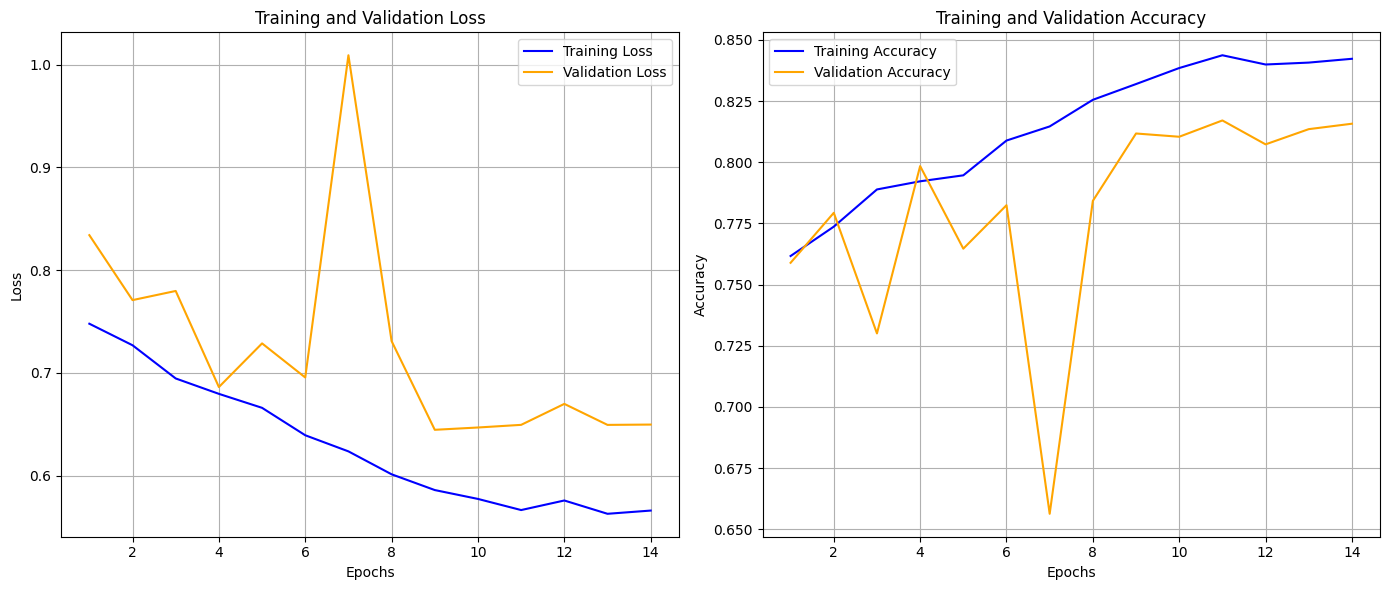

              precision    recall  f1-score  support
0.0            0.798253  0.825655  0.811723   1107.0
1.0            0.825655  0.798253  0.811723   1145.0
macro avg      0.811954  0.811954  0.811723   2252.0
weighted avg   0.812185  0.811723  0.811723   2252.0


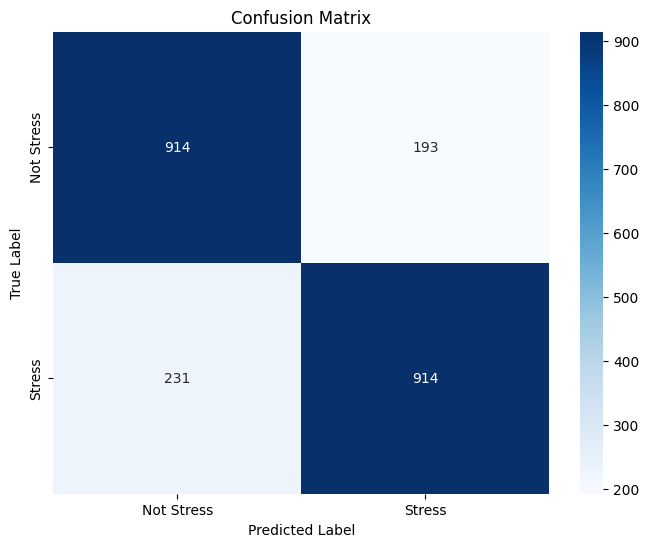

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def plot_loss_accuracy(history):
    """
    Plot training and validation loss and accuracy.
    """
    epochs = range(1, len(history.history['accuracy']) + 1)

    # Loss Graph
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss', color='blue')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy Graph
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', color='blue')
    plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy', color='orange')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def create_metrics_table(y_true, y_pred):
    """
    Generate a table of precision, recall, F1-score, and support.
    """
    report = classification_report(y_true, y_pred, output_dict=True)
    metrics_df = pd.DataFrame(report).transpose()
    metrics_df = metrics_df.drop(index="accuracy")  # Drop "accuracy" row if needed
    return metrics_df

def plot_confusion_matrix(y_true, y_pred, class_names):
    """
    Plot a confusion matrix with heatmap.
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

# Plot Loss and Accuracy
plot_loss_accuracy(history)

# Generate and display metrics table
y_pred = svm_model.predict(X_test_lstm_features)  # Example SVM predictions
metrics_table = create_metrics_table(y_test, y_pred)
print(metrics_table)

# Plot Confusion Matrix
class_names = ['Not Stress', 'Stress']  # Example class labels
plot_confusion_matrix(y_test, y_pred, class_names)


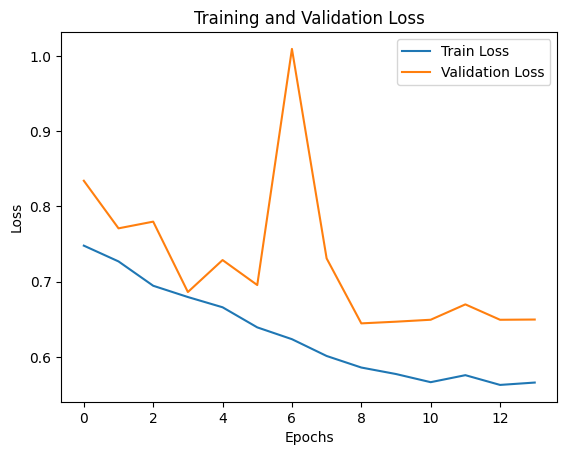

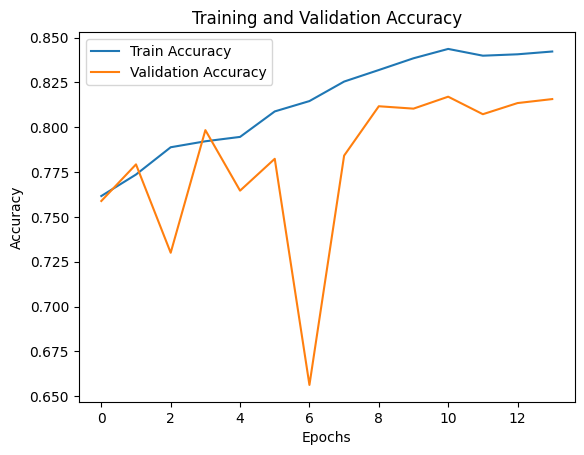

In [ ]:
import matplotlib.pyplot as plt

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


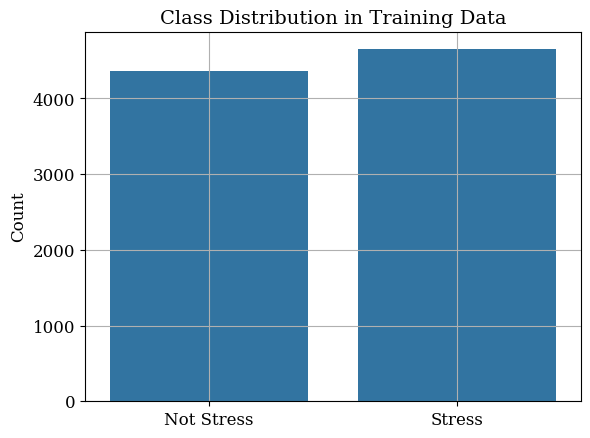

[1. 0. 1. ... 1. 1. 0.]


In [ ]:
import seaborn as sns
sns.barplot(x=['Not Stress', 'Stress'], y=[sum(y_train == 0), sum(y_train == 1)])
plt.title('Class Distribution in Training Data')
plt.ylabel('Count')
plt.grid()
plt.show()
print(y_train)

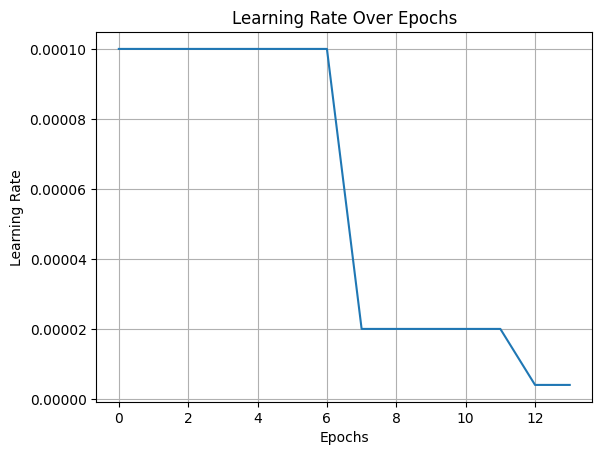

In [ ]:
# Learning rate over epochs
lr_history = [lr for lr in history.history['lr']]

# Plot learning rate vs. epochs
plt.plot(lr_history)
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Over Epochs')
plt.grid()
plt.show()


71/71 [==============================] - 2s 28ms/step


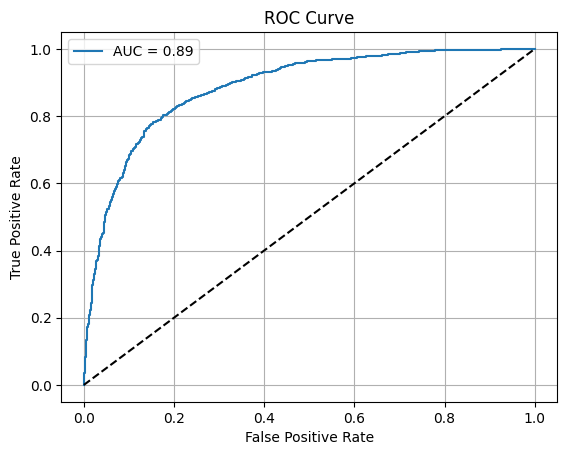

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, lstm_model_attention.predict(X_test_pad))
roc_auc = roc_auc_score(y_test, lstm_model_attention.predict(X_test_pad))

# Plot ROC curve
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random performance
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.grid()
plt.show()


71/71 [==============================] - 2s 27ms/step


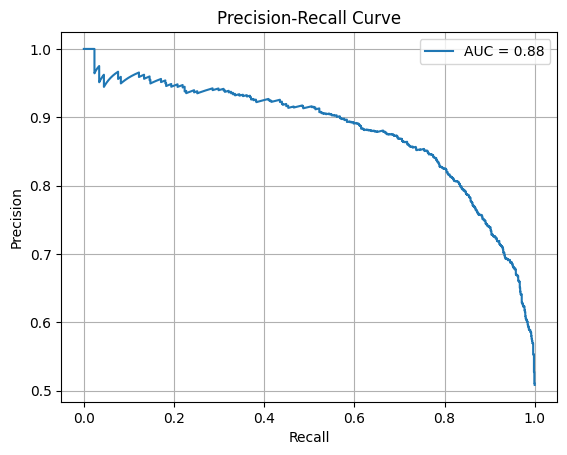

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

# Calculate precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, lstm_model_attention.predict(X_test_pad))
pr_auc = auc(recall, precision)

# Plot Precision-Recall curve
plt.plot(recall, precision, label=f'AUC = {pr_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid()
plt.show()


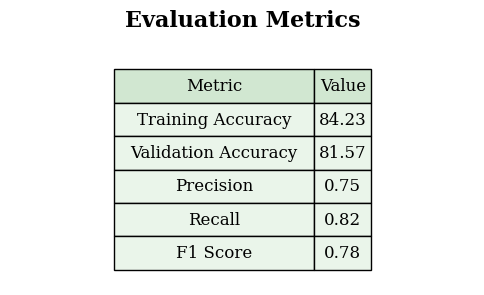

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Set font and style for better aesthetics
rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    "axes.titlesize": 14
})

# Define metrics and values (using the provided values)
metrics = ["Training Accuracy", "Validation Accuracy", "Precision", "Recall", "F1 Score"]
values = [history.history['accuracy'][-1], history.history['val_accuracy'][-1], 0.75, 0.82, 0.78]

# Convert accuracy values to percentages
values = [v * 100 if i < 2 else v for i, v in enumerate(values)]

# Create a DataFrame
data = pd.DataFrame({"Metric": metrics, "Value": [f"{v:.2f}" for v in values]})

# Plot the table as a figure
fig, ax = plt.subplots(figsize=(6, 3))  # Adjust figure size for better appearance
ax.axis('off')  # Turn off the axis

# Create the table
table = ax.table(
    cellText=data.values,
    colLabels=data.columns,
    cellLoc='center',
    loc='center',
    colColours=["#d1e7d1", "#d1e7d1"],  # Header background color (light green)
    cellColours=[["#eaf5ea"] * len(data.columns)] * len(data),  # Cell background color (light green)
)

# Format the table
table.auto_set_font_size(False)
table.set_fontsize(12)
table.auto_set_column_width(col=list(range(len(data.columns))))  # Adjust column widths
table.scale(1, 2)  # Scale table for readability

# Add a title
plt.title("Evaluation Metrics", fontsize=16, weight='bold', loc='center', pad=20)

# Save the figure (optional)
plt.savefig("evaluation_metrics_table_green.png", dpi=300, bbox_inches="tight")  # Save as high-res image

# Show the table
plt.show()
